In [1]:
import torch
from torch import nn
from torch.nn import functional as F
import seaborn as sns


经典线性代数教材是列向量优先时$Y=KQ$ 

但这里是行向量优先

行向量优先时$Y=QK^T$

两者在数学上完全等价

In [2]:
# 简单的注意力机制实现
class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

        self.w_out = nn.Linear(d_model, d_model)
    
    def forward(self, x):
        Q = self.w_q(x)
        K = self.w_k(x)
        V = self.w_v(x)
        
        scores = torch.matmul(Q, K.transpose(-2, -1))
        scores = scores / (self.d_model)**0.5

        attention_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, V)

        return self.w_out(output)

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_out = nn.Linear(d_model, d_model)
    def forward(self, x):
        batch_size = x.size(0)

        Q = self.w_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.w_k(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.w_v(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        attention_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, V)

        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.w_out(output)


In [4]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_ff, num_heads):
        super().__init__()
        # self.attention = SelfAttention(d_model)
        self.attention = MultiHeadAttention(d_model, num_heads)

        self.norm1 = nn.LayerNorm(d_model)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # 这里用的是主流的Pre-Norm 也可以用Post-Norm
        x = x + self.attention(self.norm1(x))
        x = x + self.feed_forward(self.norm2(x))
        return x

In [5]:
class TransformerEncoder(nn.Module):
    def __init__(self, d_model, d_ff, num_heads, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, d_ff, num_heads) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.norm(x)

In [10]:
class Transformer(nn.Module):
    def __init__(self, input_dim, output_dim,
                d_model, d_ff, num_heads, num_layers, max_len=512, 
                dropout=0.1):
        super().__init__()
        
        # self.embedding = nn.Embedding(input_dim, d_model)
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, d_model))

        self.dropout = nn.Dropout(dropout)
        
        self.encoder = TransformerEncoder(d_model, d_ff, num_heads, num_layers)
        
        # 5. 解码器 (将来你会写在这里)
        # self.decoder = TransformerDecoder(...) 

        self.out = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        seq_len = x.size(1)
        x = x + self.pos_embedding[:, :seq_len, :]
        x = self.dropout(x)
        memory = self.encoder(x)
        output = self.out(memory)
        return output

In [7]:
class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, output_dim, num_heads, num_layers, d_model, d_ff):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, d_model)
        self.transformer_encoder = TransformerEncoder(d_model, d_ff, num_heads, num_layers)
        self.output_layer = nn.Linear(d_model, output_dim)
        
    def forward(self, x):
        x = self.input_layer(x)
        x = self.transformer_encoder(x)
        x = self.output_layer(x)
        return x

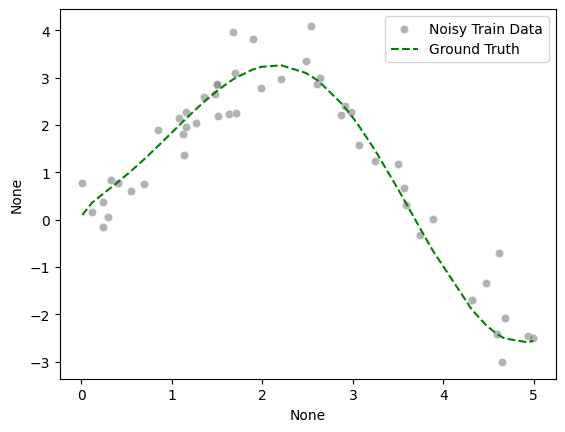

In [32]:
n_train = 50
x_train, _ = torch.sort(torch.rand(n_train) * 5.0)
def f(x):
    return x * torch.sin(x) + x**0.5
y_train = f(x_train) + torch.normal(0.0, 0.5, (x_train.size(0),))
x_test = x_train
y_truth = f(x_test)
sns.scatterplot(x=x_train, y=y_train, color='gray', alpha=0.6, label='Noisy Train Data')
sns.lineplot(x=x_test, y=y_truth, color='green', linestyle='--', label='Ground Truth')
x_train_input = x_train[None, :, None]
y_train_target = y_train[None, :, None]
x_test_input = x_test[None, :, None]



Epoch [10/100], Loss: 3.1847
Epoch [20/100], Loss: 3.1976
Epoch [30/100], Loss: 3.1205
Epoch [40/100], Loss: 1.9265
Epoch [50/100], Loss: 1.1840
Epoch [60/100], Loss: 0.3588
Epoch [70/100], Loss: 0.3523
Epoch [80/100], Loss: 0.3886
Epoch [90/100], Loss: 0.1854
Epoch [100/100], Loss: 0.1372


<Axes: xlabel='None', ylabel='None'>

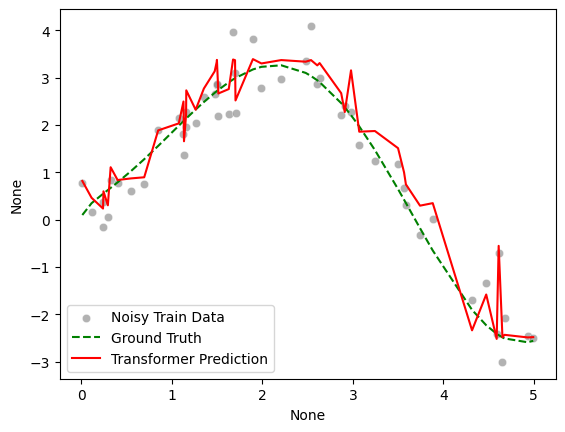

In [33]:
model = Transformer(input_dim=1, output_dim=1,
                    d_model=64, d_ff=256,
                    num_heads=4, num_layers=4)
# model = TransformerRegressor(input_dim=1, output_dim=1, num_heads=4, num_layers=4, d_model=64, d_ff=128)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

epoch_num = 100
for epoch in range(epoch_num):
    optimizer.zero_grad()
    y_pred = model(x_train_input)
    loss = criterion(y_pred, y_train_target)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epoch_num}], Loss: {loss.item():.4f}')

model.eval()
with torch.no_grad():
    pred_y = model(x_test_input)

x_np = x_test
y_true_np = y_truth
pred_y_np = pred_y.detach()[0,:,0]

sns.scatterplot(x=x_train, y=y_train, color='gray', alpha=0.6, label='Noisy Train Data')
sns.lineplot(x=x_np, y=y_true_np, color='green', linestyle='--', label='Ground Truth')
sns.lineplot(x=x_np, y=pred_y_np, color='red', label='Transformer Prediction')
